# Tableaux de bord décisionnels — Projet Data Warehouse Films

**Source :** Base de données PostgreSQL `movie_dwh` (schéma `Sch_DWH`)

**Outil :** Matplotlib

**KPIs visualisés :**
1. Revenus totaux par genre
2. Top 10 studios par revenus
3. Évolution du budget moyen par année
4. Distribution du ROI (rentabilité)
5. Score critique vs score utilisateur
6. Revenus par saison de sortie
7. Budget vs Profit (nuage de points)
8. Nombre de films par décennie

## 1. Importation des bibliothèques

In [1]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

print('Bibliothèques importées avec succès')

Bibliothèques importées avec succès


## 2. Connexion à PostgreSQL

In [3]:
pgconn = psycopg2.connect(
    database = 'movie_DWH',
    host     = 'localhost',
    user     = 'postgres',
    password = 'system',
    port     = 5432
)
cur = pgconn.cursor()
cur.execute('SET search_path TO "Sch_DWH"')
print('Connexion établie')

Connexion établie


## KPI 1 — Revenus totaux par genre

**Question :** Quels genres génèrent le plus de revenus au box-office ?

**Type de graphique :** Histogramme horizontal

In [4]:
# Requête : revenus totaux par genre
cur.execute("""
    SELECT m.primary_genre,
           SUM(f.revenue) AS revenu_total
    FROM fact_box_office f
    INNER JOIN dim_movie m ON f.movie_id = m.movie_id
    GROUP BY m.primary_genre
    ORDER BY revenu_total DESC
    LIMIT 10
""")
rows = cur.fetchall()
print('Données récupérées :')
for row in rows:
    print(row)

Données récupérées :
('Action', Decimal('73842919609'))
('Adventure', Decimal('56108800948'))
('Comedy', Decimal('53037118804'))
('Drama', Decimal('51252164870'))
('Animation', Decimal('24751140220'))
('Fantasy', Decimal('16166326541'))
('Science Fiction', Decimal('13565346696'))
('Horror', Decimal('13252095127'))
('Thriller', Decimal('11384020332'))
('Crime', Decimal('9408596694'))


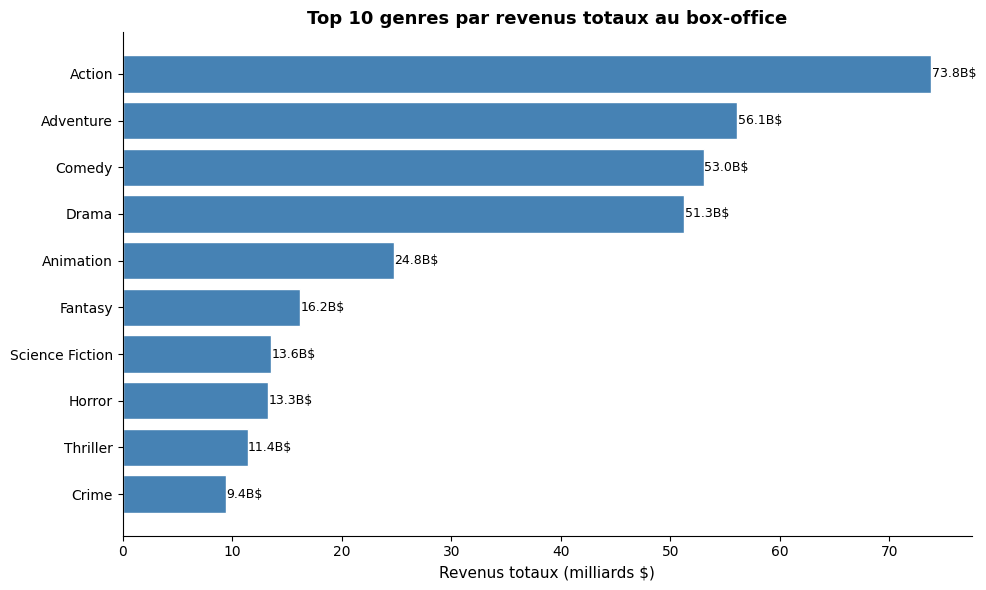

KPI 1 sauvegardé


In [5]:
# Préparer les données
genres  = [row[0] for row in rows]
revenus = [row[1] / 1_000_000_000 for row in rows]  # en milliards

# Tracer le graphique
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(genres[::-1], revenus[::-1], color='steelblue', edgecolor='white')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, revenus[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}B$', va='center', fontsize=9)

ax.set_xlabel('Revenus totaux (milliards $)', fontsize=11)
ax.set_title('Top 10 genres par revenus totaux au box-office', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kpi1_revenus_par_genre.png', dpi=150)
plt.show()
print('KPI 1 sauvegardé')

## KPI 2 — Top 10 studios par revenus totaux

**Question :** Quels studios dominent le box-office mondial ?

**Type de graphique :** Histogramme vertical

In [6]:
# Requête : top 10 studios par revenus
cur.execute("""
    SELECT s.studio_name,
           SUM(f.revenue) AS revenu_total,
           COUNT(*) AS nb_films
    FROM fact_box_office f
    INNER JOIN dim_studio s ON f.studio_id = s.studio_id
    GROUP BY s.studio_name
    ORDER BY revenu_total DESC
    LIMIT 10
""")
rows = cur.fetchall()
print('Données récupérées :')
for row in rows:
    print(row)

Données récupérées :
('Paramount Pictures', Decimal('32951247811'), 237)
('Universal Pictures', Decimal('29907847458'), 223)
('Columbia Pictures', Decimal('24522271427'), 162)
('Twentieth Century Fox Film Corporation', Decimal('22488981769'), 158)
('Walt Disney Pictures', Decimal('20144934176'), 86)
('New Line Cinema', Decimal('13529942493'), 135)
('Village Roadshow Pictures', Decimal('11819054241'), 64)
('DreamWorks SKG', Decimal('10522249688'), 54)
('DreamWorks Animation', Decimal('6782789915'), 14)
('Summit Entertainment', Decimal('5977794161'), 40)


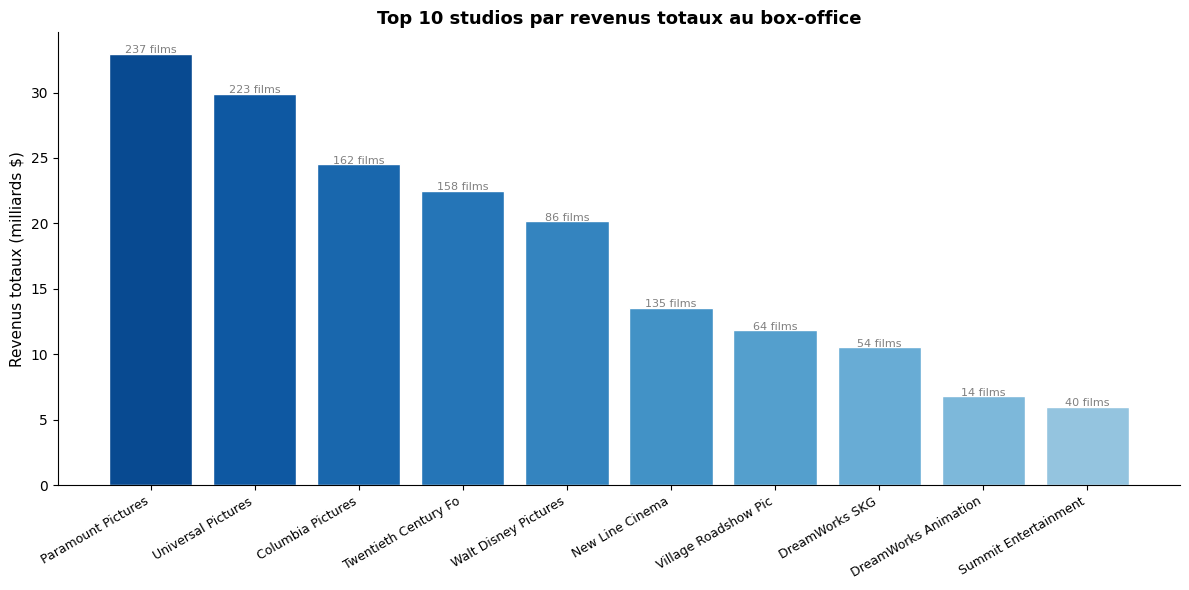

KPI 2 sauvegardé


In [7]:
# Préparer les données
studios  = [row[0][:20] for row in rows]  # tronquer les noms longs
revenus  = [row[1] / 1_000_000_000 for row in rows]
nb_films = [row[2] for row in rows]

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(studios)))
bars = ax.bar(studios, revenus, color=colors[::-1], edgecolor='white')

# Ajouter le nombre de films au-dessus de chaque barre
for bar, nb in zip(bars, nb_films):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{nb} films', ha='center', fontsize=8, color='gray')

ax.set_ylabel('Revenus totaux (milliards $)', fontsize=11)
ax.set_title('Top 10 studios par revenus totaux au box-office', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kpi2_top_studios.png', dpi=150)
plt.show()
print('KPI 2 sauvegardé')

## KPI 3 — Évolution du budget moyen par année

**Question :** Comment les budgets des films ont-ils évolué au fil du temps ?

**Type de graphique :** Courbe

In [8]:
# Requête : budget moyen par année
cur.execute("""
    SELECT d.year,
           AVG(f.budget)  AS budget_moyen,
           AVG(f.revenue) AS revenu_moyen
    FROM fact_box_office f
    INNER JOIN dim_date d ON f.date_id = d.date_id
    WHERE d.year BETWEEN 1980 AND 2023
    GROUP BY d.year
    ORDER BY d.year
""")
rows = cur.fetchall()
print('Données récupérées :')
for row in rows[:5]:
    print(row)

Données récupérées :
(1980, Decimal('17000000.000000000000'), Decimal('80686403.187500000000'))
(1981, Decimal('13170833.333333333333'), Decimal('54788690.250000000000'))
(1982, Decimal('14452941.176470588235'), Decimal('108128362.70588235'))
(1983, Decimal('19189000.000000000000'), Decimal('86342088.833333333333'))
(1984, Decimal('15102083.333333333333'), Decimal('73071174.166666666667'))


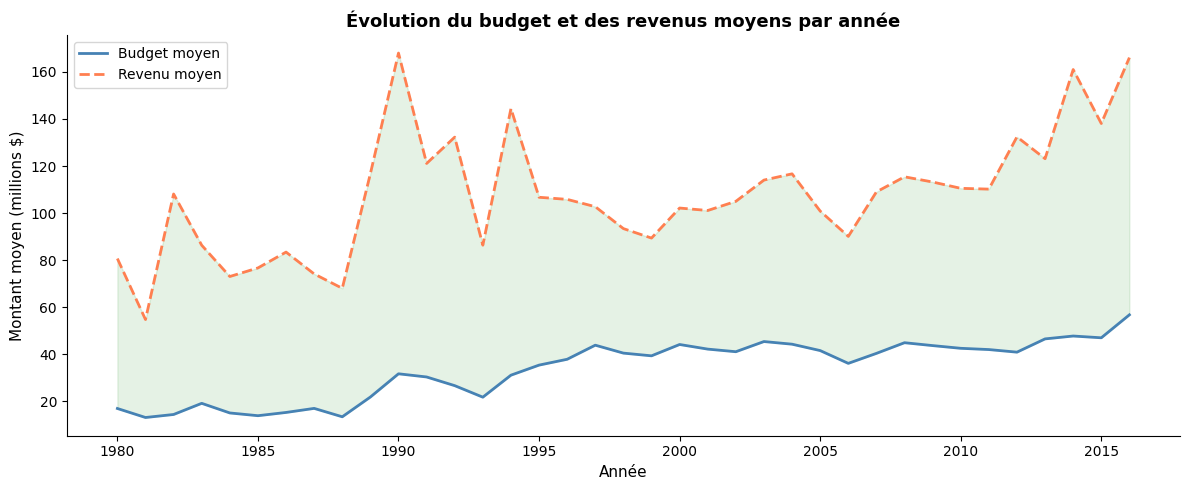

KPI 3 sauvegardé


In [9]:
# Préparer les données
annees         = [row[0] for row in rows]
budgets_moy    = [row[1] / 1_000_000 for row in rows]  # en millions
revenus_moy    = [row[2] / 1_000_000 for row in rows]

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(annees, budgets_moy, color='steelblue', linewidth=2, label='Budget moyen')
ax.plot(annees, revenus_moy, color='coral',     linewidth=2, label='Revenu moyen', linestyle='--')

ax.fill_between(annees, budgets_moy, revenus_moy, alpha=0.1, color='green')

ax.set_xlabel('Année', fontsize=11)
ax.set_ylabel('Montant moyen (millions $)', fontsize=11)
ax.set_title('Évolution du budget et des revenus moyens par année', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kpi3_evolution_budget.png', dpi=150)
plt.show()
print('KPI 3 sauvegardé')

## KPI 4 — Distribution du ROI par genre

**Question :** Quels genres sont les plus rentables en termes de retour sur investissement ?

**Type de graphique :** Boîte à moustaches (boxplot)

In [10]:
# Requête : ROI par genre
cur.execute("""
    SELECT m.primary_genre, f.roi
    FROM fact_box_office f
    INNER JOIN dim_movie m ON f.movie_id = m.movie_id
    WHERE f.roi BETWEEN -1 AND 20
    AND m.primary_genre != 'Unknown'
    ORDER BY m.primary_genre
""")
rows = cur.fetchall()
print(f'Données récupérées : {len(rows)} lignes')

Données récupérées : 3063 lignes


C:\Users\Hala\AppData\Local\Temp\ipykernel_46052\2932184822.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groupes, labels=genres_valides, patch_artist=True, notch=False)


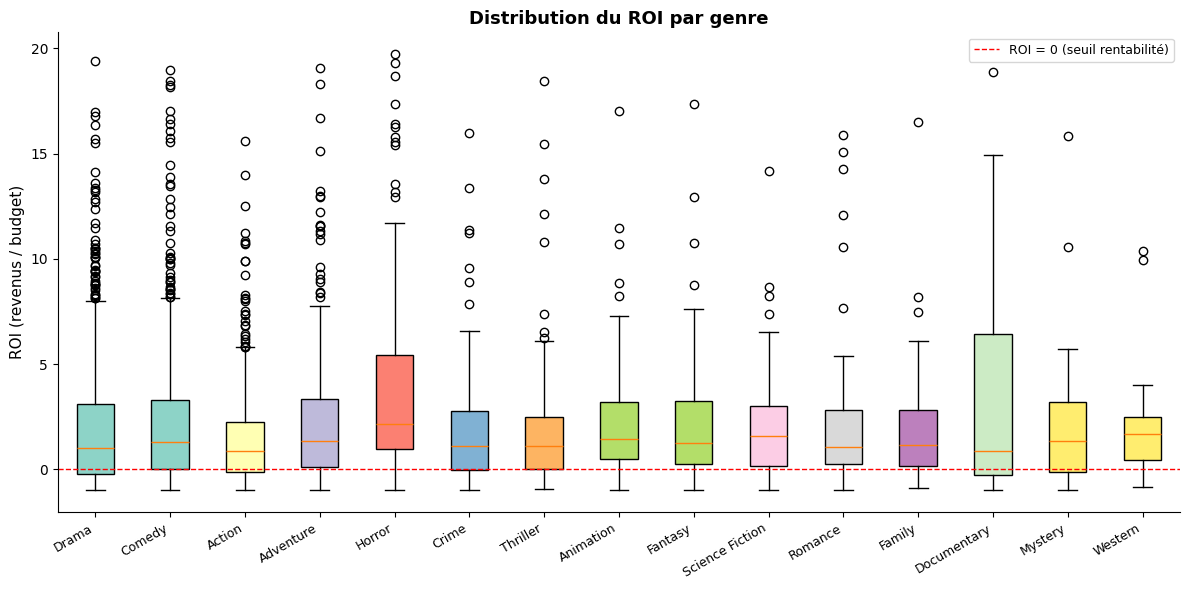

KPI 4 sauvegardé


In [11]:
# Organiser les données par genre
df_roi = pd.DataFrame(rows, columns=['genre', 'roi'])

# Garder les genres avec au moins 20 films
genres_valides = df_roi['genre'].value_counts()
genres_valides = genres_valides[genres_valides >= 20].index.tolist()
df_roi = df_roi[df_roi['genre'].isin(genres_valides)]

# Grouper par genre
groupes = [df_roi[df_roi['genre'] == g]['roi'].values for g in genres_valides]

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(groupes, labels=genres_valides, patch_artist=True, notch=False)

# Colorier les boîtes
colors = plt.cm.Set3(np.linspace(0, 1, len(genres_valides)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

ax.axhline(y=0, color='red', linestyle='--', linewidth=1, label='ROI = 0 (seuil rentabilité)')
ax.set_ylabel('ROI (revenus / budget)', fontsize=11)
ax.set_title('Distribution du ROI par genre', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kpi4_roi_par_genre.png', dpi=150)
plt.show()
print('KPI 4 sauvegardé')

## KPI 5 — Score critique vs Score utilisateur

**Question :** Les films bien notés par les critiques sont-ils aussi appréciés du public ?

**Type de graphique :** Nuage de points avec droite de régression

In [12]:
# Requête : metascore vs user_score pour les films ayant les deux
cur.execute("""
    SELECT r.metascore, r.user_score, m.primary_genre
    FROM fact_ratings r
    INNER JOIN dim_movie m ON r.movie_id = m.movie_id
    WHERE r.metascore IS NOT NULL
    AND r.user_score  IS NOT NULL
    AND r.metascore > 0
    AND r.user_score > 0
""")
rows = cur.fetchall()
print(f'Films avec les deux scores : {len(rows)}')

Films avec les deux scores : 0


Films avec metascore : 0
Pas assez de données Metacritic — affichage score TMDB vs popularité
Films récupérés : 3113


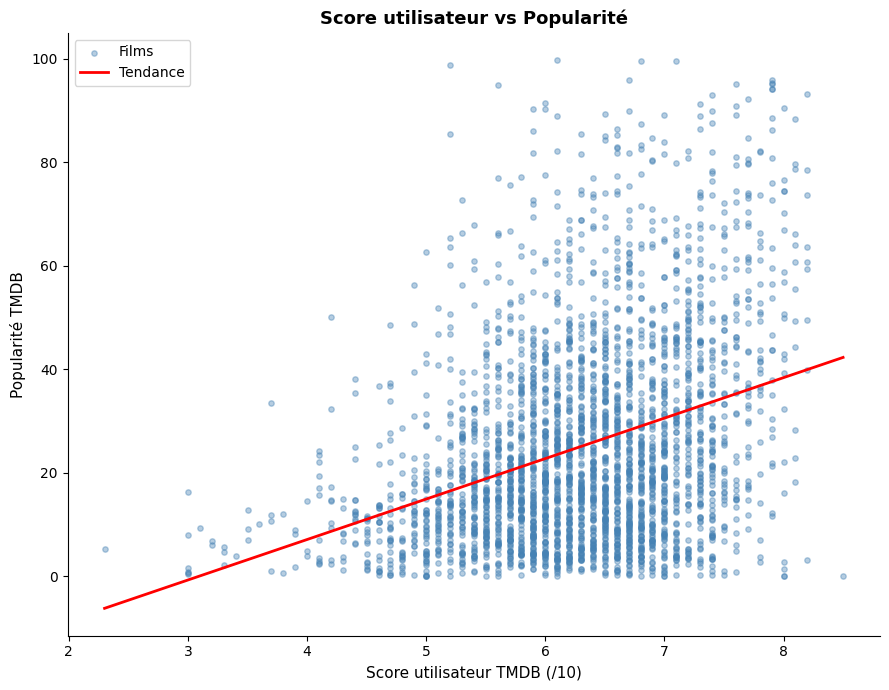

KPI 5 sauvegardé


In [14]:
# Check if we have enough data for critic vs user comparison
print(f'Films avec metascore : {df_scores.shape[0]}')

if df_scores.shape[0] < 5:
    print('Pas assez de données Metacritic — affichage score TMDB vs popularité')
    
    # Fallback : user_score vs popularity from fact_ratings
    cur.execute("""
        SELECT r.user_score, r.popularity, m.primary_genre
        FROM fact_ratings r
        INNER JOIN dim_movie m ON r.movie_id = m.movie_id
        WHERE r.user_score > 0
        AND   r.popularity > 0
        AND   r.popularity < 100
    """)
    rows2 = cur.fetchall()
    df_scores = pd.DataFrame(rows2, columns=['user_score', 'popularity', 'genre'])
    print(f'Films récupérés : {len(df_scores)}')

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.scatter(df_scores['user_score'], df_scores['popularity'],
               alpha=0.4, color='steelblue', s=15, label='Films')

    # Droite de régression
    z = np.polyfit(df_scores['user_score'], df_scores['popularity'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_scores['user_score'].min(), df_scores['user_score'].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendance')

    ax.set_xlabel('Score utilisateur TMDB (/10)', fontsize=11)
    ax.set_ylabel('Popularité TMDB', fontsize=11)
    ax.set_title('Score utilisateur vs Popularité', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

else:
    # Original chart with metascore
    df_scores['metascore_10'] = df_scores['metascore'] / 10

    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(df_scores['metascore_10'], df_scores['user_score'],
               alpha=0.4, color='steelblue', s=20, label='Films')

    z = np.polyfit(df_scores['metascore_10'], df_scores['user_score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_scores['metascore_10'].min(), df_scores['metascore_10'].max(), 100)
    ax.plot(x_line, p(x_line), color='red', linewidth=2, label='Tendance')
    ax.plot([0, 10], [0, 10], color='gray', linestyle='--', linewidth=1, label='Égalité parfaite')

    ax.set_xlabel('Metascore normalisé (/10)', fontsize=11)
    ax.set_ylabel('Score utilisateur TMDB (/10)', fontsize=11)
    ax.set_title('Score critique vs Score utilisateur', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kpi5_scores.png', dpi=150)
plt.show()
print('KPI 5 sauvegardé')

## KPI 6 — Revenus moyens par saison de sortie

**Question :** Quelle saison est la plus rentable pour sortir un film ?

**Type de graphique :** Camembert

In [15]:
# Requête : revenus totaux par saison
cur.execute("""
    SELECT d.season,
           SUM(f.revenue)  AS revenu_total,
           COUNT(*)        AS nb_films
    FROM fact_box_office f
    INNER JOIN dim_date d ON f.date_id = d.date_id
    WHERE d.season IS NOT NULL
    GROUP BY d.season
    ORDER BY revenu_total DESC
""")
rows = cur.fetchall()
print('Données récupérées :')
for row in rows:
    print(row)

Données récupérées :
('Ete', Decimal('107157995338'), 821)
('Printemps', Decimal('83306995808'), 685)
('Automne', Decimal('82129441700'), 927)
('Hiver', Decimal('71872085821'), 748)


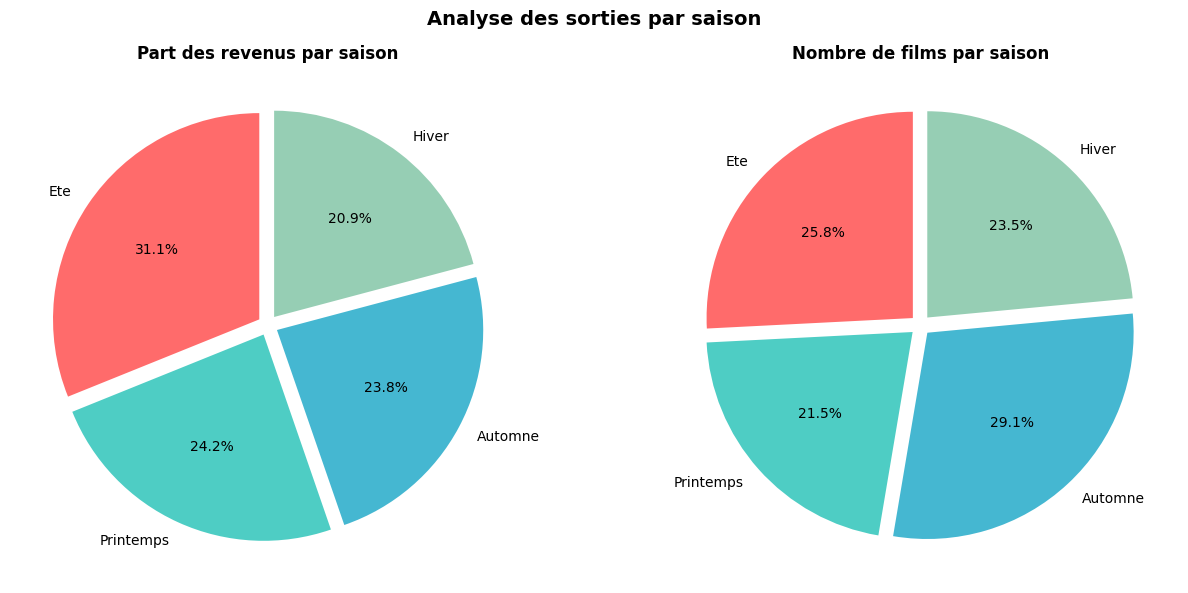

KPI 6 sauvegardé


In [16]:
# Préparer les données
saisons  = [row[0] for row in rows]
revenus  = [row[1] for row in rows]
nb_films = [row[2] for row in rows]

couleurs = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
explode  = [0.05] * len(saisons)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Camembert des revenus
axes[0].pie(revenus, labels=saisons, autopct='%1.1f%%',
            colors=couleurs, explode=explode, startangle=90)
axes[0].set_title('Part des revenus par saison', fontsize=12, fontweight='bold')

# Camembert du nombre de films
axes[1].pie(nb_films, labels=saisons, autopct='%1.1f%%',
            colors=couleurs, explode=explode, startangle=90)
axes[1].set_title('Nombre de films par saison', fontsize=12, fontweight='bold')

plt.suptitle('Analyse des sorties par saison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('kpi6_saisons.png', dpi=150)
plt.show()
print('KPI 6 sauvegardé')

## KPI 7 — Budget vs Profit

**Question :** Un budget élevé garantit-il un profit élevé ?

**Type de graphique :** Nuage de points coloré par genre

In [17]:
# Requête : budget vs profit avec genre
cur.execute("""
    SELECT f.budget, f.profit, m.primary_genre
    FROM fact_box_office f
    INNER JOIN dim_movie m ON f.movie_id = m.movie_id
    WHERE f.budget  BETWEEN 1000000 AND 400000000
    AND   f.profit  BETWEEN -200000000 AND 1000000000
    AND   m.primary_genre != 'Unknown'
""")
rows = cur.fetchall()
print(f'Données récupérées : {len(rows)} films')

Données récupérées : 3066 films


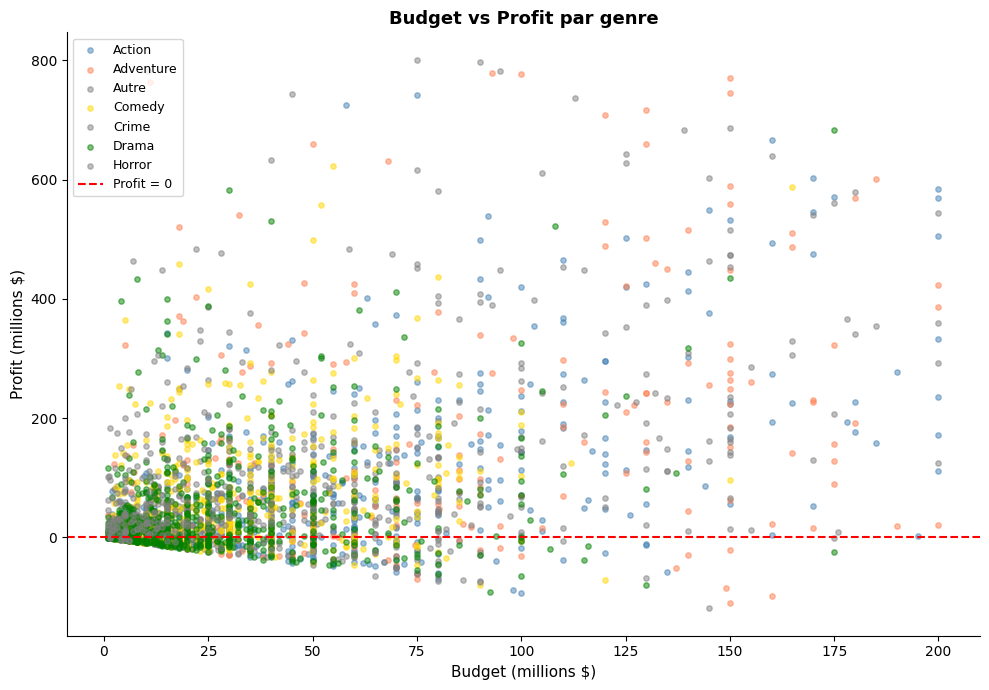

KPI 7 sauvegardé


In [18]:
df_bp = pd.DataFrame(rows, columns=['budget', 'profit', 'genre'])

# Top 6 genres seulement pour la légende
top_genres = df_bp['genre'].value_counts().head(6).index.tolist()
df_bp['genre_label'] = df_bp['genre'].apply(lambda g: g if g in top_genres else 'Autre')

fig, ax = plt.subplots(figsize=(10, 7))

couleurs_genres = {'Action':'steelblue','Adventure':'coral','Drama':'green',
                   'Comedy':'gold','Animation':'purple','Thriller':'brown','Autre':'gray'}

for genre, group in df_bp.groupby('genre_label'):
    ax.scatter(group['budget']/1e6, group['profit']/1e6,
               label=genre, alpha=0.5, s=15,
               color=couleurs_genres.get(genre, 'gray'))

# Ligne de profit nul
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Profit = 0')

ax.set_xlabel('Budget (millions $)', fontsize=11)
ax.set_ylabel('Profit (millions $)', fontsize=11)
ax.set_title('Budget vs Profit par genre', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('kpi7_budget_vs_profit.png', dpi=150)
plt.show()
print('KPI 7 sauvegardé')

## KPI 8 — Nombre de films et revenus moyens par décennie

**Question :** Comment la production cinématographique a-t-elle évolué par décennie ?

**Type de graphique :** Histogramme double axe

In [19]:
# Requête : films et revenus par décennie
cur.execute("""
    SELECT (d.year / 10) * 10        AS decennie,
           COUNT(*)                  AS nb_films,
           AVG(f.revenue) / 1000000  AS revenu_moyen_M
    FROM fact_box_office f
    INNER JOIN dim_date d ON f.date_id = d.date_id
    WHERE d.year BETWEEN 1960 AND 2023
    GROUP BY decennie
    ORDER BY decennie
""")
rows = cur.fetchall()
print('Données récupérées :')
for row in rows:
    print(row)

Données récupérées :
(1960, 59, Decimal('37.7733717118644068'))
(1970, 81, Decimal('79.3685867654320988'))
(1980, 204, Decimal('81.3126998186274510'))
(1990, 537, Decimal('106.6232838007448800'))
(2000, 1320, Decimal('106.5447024628787900'))
(2010, 917, Decimal('130.4712406139585600'))


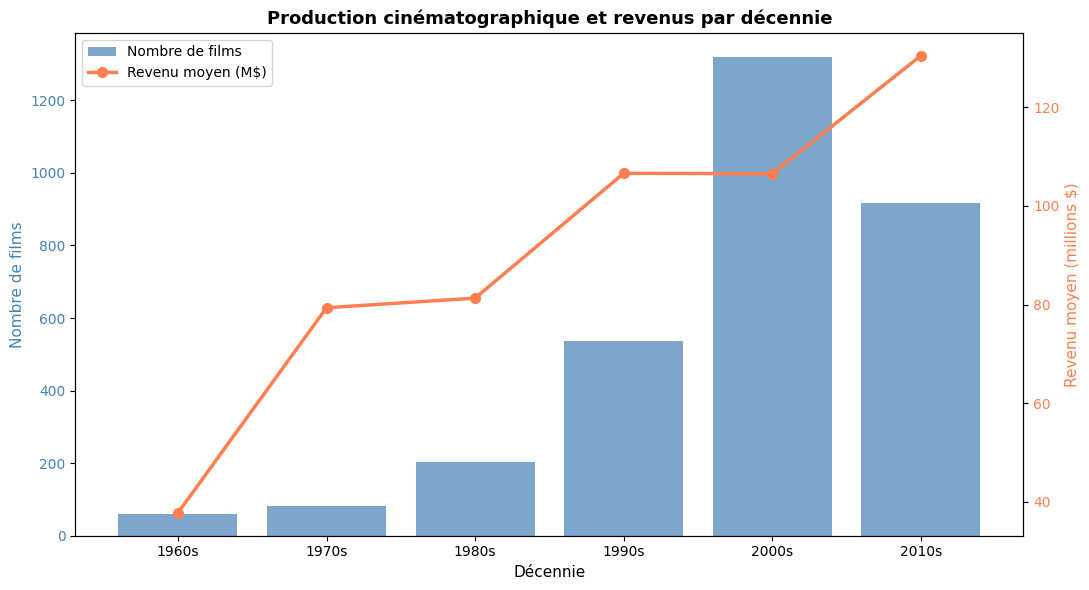

KPI 8 sauvegardé


In [20]:
decennies    = [str(row[0]) + 's' for row in rows]
nb_films     = [row[1] for row in rows]
revenus_moy  = [float(row[2]) for row in rows]

fig, ax1 = plt.subplots(figsize=(11, 6))

# Axe 1 : nombre de films (barres)
bars = ax1.bar(decennies, nb_films, color='steelblue', alpha=0.7, label='Nombre de films')
ax1.set_ylabel('Nombre de films', color='steelblue', fontsize=11)
ax1.tick_params(axis='y', labelcolor='steelblue')

# Axe 2 : revenu moyen (courbe)
ax2 = ax1.twinx()
ax2.plot(decennies, revenus_moy, color='coral', linewidth=2.5,
         marker='o', markersize=7, label='Revenu moyen (M$)')
ax2.set_ylabel('Revenu moyen (millions $)', color='coral', fontsize=11)
ax2.tick_params(axis='y', labelcolor='coral')

ax1.set_title('Production cinématographique et revenus par décennie',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Décennie', fontsize=11)

# Légende combinée
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('kpi8_decennies.png', dpi=150)
plt.show()
print('KPI 8 sauvegardé')

## Fermeture de la connexion

In [21]:
cur.close()
pgconn.close()
print('Connexion fermée — tous les graphiques sauvegardés')

Connexion fermée — tous les graphiques sauvegardés


## Résumé des KPIs

| # | Question décisionnelle | Graphique | Fichier |
|---|---|---|---|
| 1 | Quels genres génèrent le plus de revenus ? | Histogramme horizontal | kpi1_revenus_par_genre.png |
| 2 | Quels studios dominent le box-office ? | Histogramme vertical | kpi2_top_studios.png |
| 3 | Comment les budgets évoluent-ils ? | Courbe | kpi3_evolution_budget.png |
| 4 | Quels genres sont les plus rentables ? | Boxplot | kpi4_roi_par_genre.png |
| 5 | Critiques vs public : accord ou désaccord ? | Nuage de points | kpi5_critique_vs_public.png |
| 6 | Quelle saison est la plus rentable ? | Camembert | kpi6_saisons.png |
| 7 | Budget élevé = profit élevé ? | Nuage de points | kpi7_budget_vs_profit.png |
| 8 | Évolution de la production par décennie ? | Double axe | kpi8_decennies.png |